# Data features

In this notebook we will look closely at the features of the dataset, how they correlate, how data is distributed.  
The data has been cleaned and some insights already gained.  
If you haven't seen the first [notebook](EDA.ipynb), I strongly recommend browsing through it at least briefly.  
Also the data used here is a result of processing in the first notebook, so it should be launched at least once.

The data was taken from the [official website](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).  
Information about the dataset:
| Field Name | Description |
|------------|-------------|
| **VendorID** | A code indicating the TPEP provider that provided the record.<br>1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix |
| **tpep_pickup_datetime** | The date and time when the meter was engaged. |
| **tpep_dropoff_datetime** | The date and time when the meter was disengaged. |
| **passenger_count** | The number of passengers in the vehicle. |
| **trip_distance** | The elapsed trip distance in miles reported by the taximeter. |
| **RatecodeID** | The final rate code in effect at the end of the trip.<br>1 = Standard rate<br>2 = JFK<br>3 = Newark<br>4 = Nassau or Westchester<br>5 = Negotiated fare<br>6 = Group ride<br>99 = Null/unknown |
| **store_and_fwd_flag** | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server.<br>Y = store and forward trip<br>N = not a store and forward trip |
| **PULocationID** | TLC Taxi Zone in which the taximeter was engaged. |
| **DOLocationID** | TLC Taxi Zone in which the taximeter was disengaged. |
| **payment_type** | A numeric code signifying how the passenger paid for the trip.<br>0 = Flex Fare trip<br>1 = Credit card<br>2 = Cash<br>3 = No charge<br>4 = Dispute<br>5 = Unknown<br>6 = Voided trip |
| **fare_amount** | The time-and-distance fare calculated by the meter. For additional information on the following columns, see https://www.nyc.gov/site/tlc/passengers/taxi-fare.page |
| **extra** | Miscellaneous extras and surcharges. |
| **mta_tax** | Tax that is automatically triggered based on the metered rate in use. |
| **tip_amount** | Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| **tolls_amount** | Total amount of all tolls paid in trip. |
| **improvement_surcharge** | Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
| **total_amount** | The total amount charged to passengers. Does not include cash tips. |
| **congestion_surcharge** | Total amount collected in trip for NYS congestion surcharge. |
| **airport_fee** | For pick up only at LaGuardia and John F. Kennedy Airports. |
| **cbd_congestion_fee** | Per-trip charge for MTA's Congestion Relief Zone starting Jan. 5, 2025. |

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as sps

In [2]:
df = pd.read_parquet('../data/processed/clean_data.parquet')

## Notebook settings

In [3]:
turn_on_graphs = True  # Enable or disable graphic visuals
pd.set_option('display.max_columns', None)  # Show all columns for dataframes

A custom function to plot feature distributions.

In [4]:
def plot_distribution(series, col_name, u_count = 10):
    if turn_on_graphs:
        plt.figure(figsize=(10, 6))
        
        is_datetime = pd.api.types.is_datetime64_any_dtype(series)
        data_no_na = series.dropna()
        unique_count = data_no_na.nunique()
        
        if unique_count < u_count:
            counts = series.value_counts(dropna=True).sort_index()
            
            
            if is_datetime:
                x_labels = [mdates.num2date(mdates.date2num(val)).strftime('%Y-%m-%d %H:%M:%S') 
                            for val in counts.index]
            else:
                x_labels = counts.index.astype(str)
            
            bars = plt.bar(range(len(counts)), counts.values, tick_label=x_labels,
                           edgecolor='black', alpha=0.7)
            plt.xticks(rotation=45, ha='right')
            plt.xlabel(col_name)
    
            for bar, count in zip(bars, counts.values):
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                         f'{count}', ha='center', va='bottom', fontsize=9)
        else:
            if is_datetime:
                dates_num = mdates.date2num(data_no_na.to_numpy())
                plt.hist(dates_num, bins=50, edgecolor='black', alpha=0.7)
                locator = mdates.AutoDateLocator()
                formatter = mdates.AutoDateFormatter(locator)
                plt.gca().xaxis.set_major_locator(locator)
                plt.gca().xaxis.set_major_formatter(formatter)
                plt.gcf().autofmt_xdate()
                plt.xlabel('Date/time')
            else:
                plt.hist(data_no_na, bins=50, edgecolor='black', alpha=0.7)
                plt.xlabel(col_name)
        
        plt.ylabel('Frequency')
        plt.title(f'Feature distribution: {col_name}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print('Graphs are turned off')

## Correlations

First let's modify some features. Time and date in the dataset are considered one field. We'll modify them to show separately the date, the day of the week, and the time sector. We'll split the day into 48 half-hour periods, so as to narrow down the time at which a taxi could be called.  

In [5]:
(df['tpep_pickup_datetime'].dt.day != df['tpep_dropoff_datetime'].dt.day).sum()

np.int64(38852)

In most cases the day of pickup and dropoff is the same, so we will only create separate dropoff half-hour periods, so as to not make too many features.

In [6]:
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek + 1  # Monday - 1, Sunday - 7
df['pickup_day_n'] = df['tpep_pickup_datetime'].dt.day  # From 1 to 31
df['pickup_half_hour_n'] = (df['tpep_pickup_datetime'].dt.hour * 2 + (df['tpep_pickup_datetime'].dt.minute // 30) + 1)
df['dropoff_half_hour_n'] = (df['tpep_dropoff_datetime'].dt.hour * 2 + (df['tpep_dropoff_datetime'].dt.minute // 30) + 1)

Let's see how the new features are distributed.

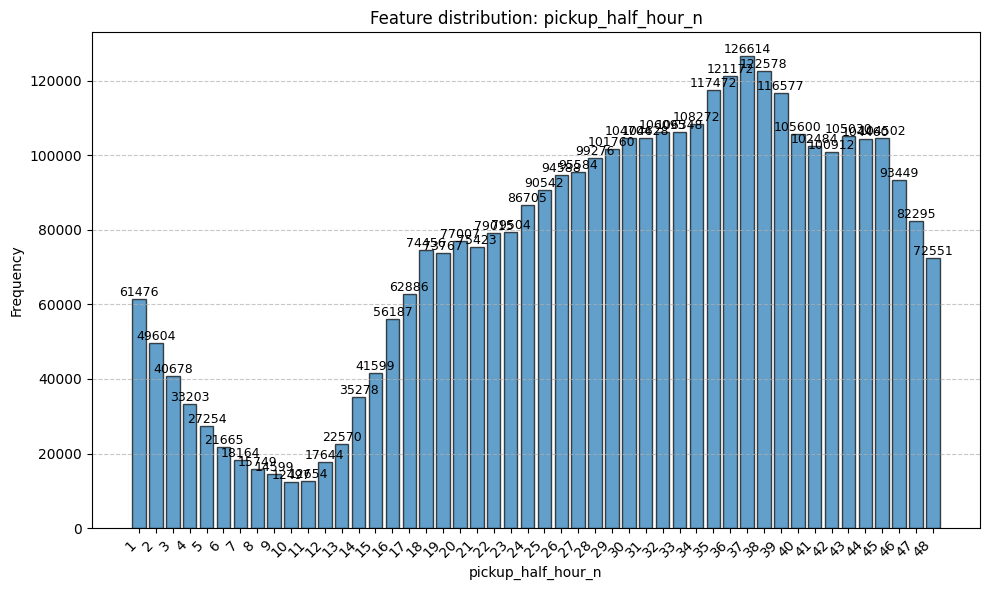

In [7]:
plot_distribution(df['pickup_half_hour_n'], 'pickup_half_hour_n', u_count = 50)

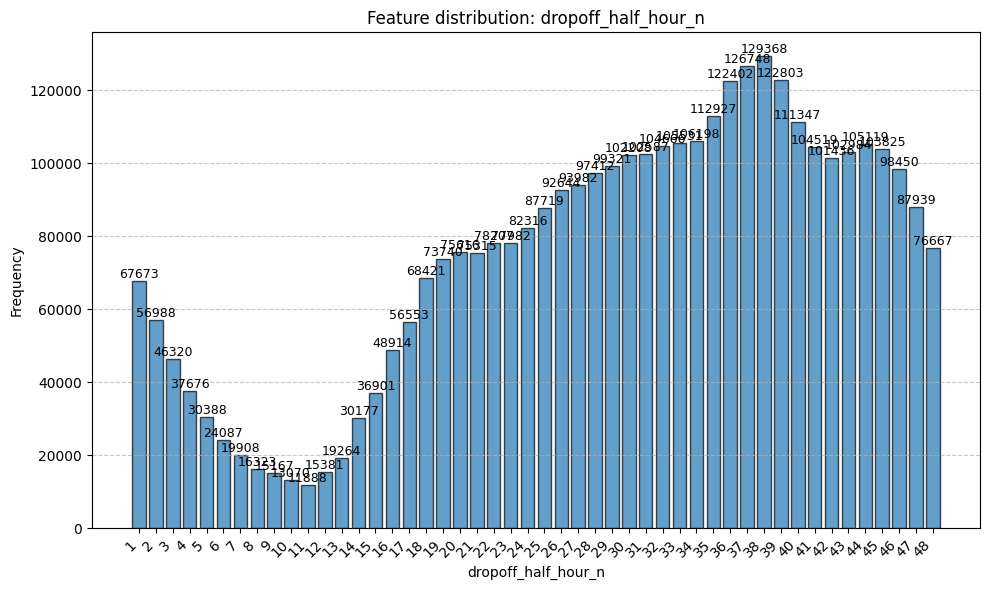

In [8]:
plot_distribution(df['dropoff_half_hour_n'], 'dropoff_half_hour_n', u_count = 50)

Nothing too unusual here. The least amount of taxi calls is around 5-5:30 AM, while the peak is at about 7 PM

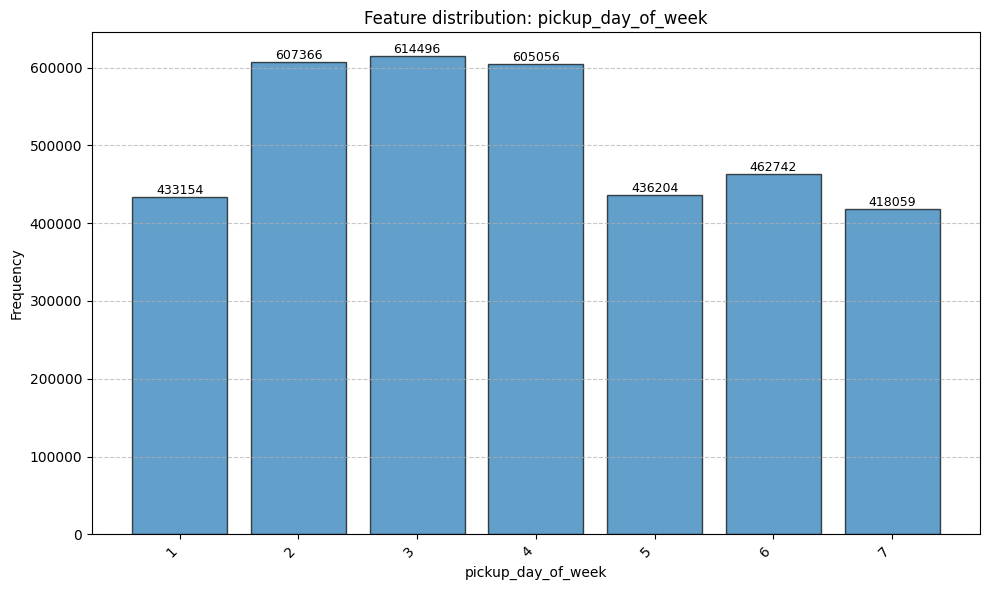

In [9]:
plot_distribution(df['pickup_day_of_week'], 'pickup_day_of_week')

Tuesday, Wednesday and Thursday seem to have about 1.5 times more taxis called. That is interesting. 

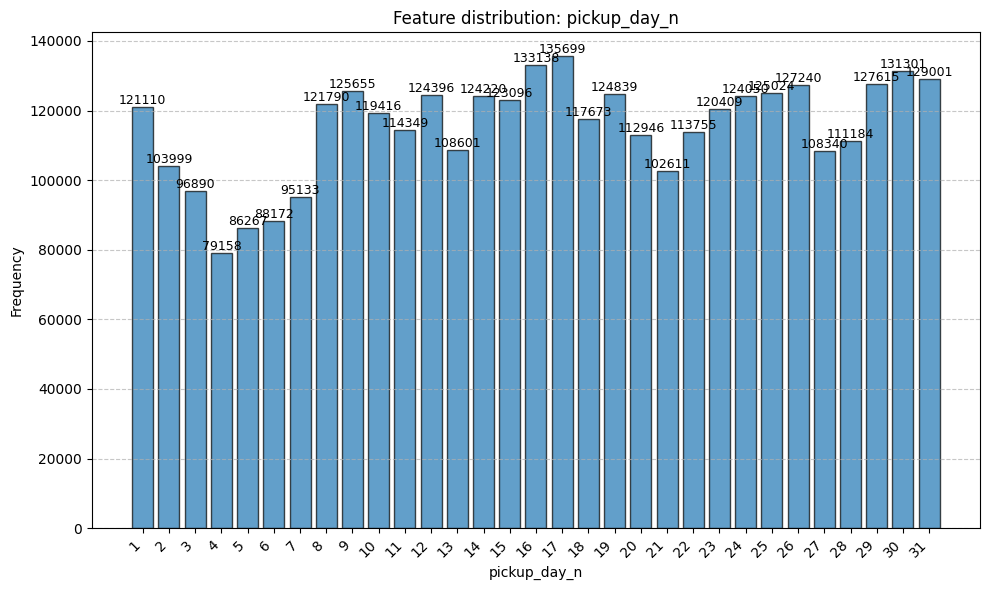

In [10]:
plot_distribution(df['pickup_day_n'], 'pickup_day_n', u_count = 50)

The distribution throughout the month is roughly uniform, except for a small fall around July 4th, on which Americans celebrate Independence Day.  
    No surprises here.